# Cart Abandonment Analysis
**Project:** Reducing Cart Abandonment at an Undisclosed E-Commerce Platform  
**Dataset:** E-Commerce Behavior Data — October 2019 (Open CDP via Kaggle)

## 1. Setup & Imports
Import all required libraries for data manipulation and visualisation.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')

## 2. Load Data
Load October 2019 event data into a single dataframe.

In [4]:
df = pd.read_csv('data/2019-Oct.csv')

print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print(f"\nColumns: {list(df.columns)}")

Total rows: 42,448,764
Total columns: 9

Columns: ['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']


## 3. Explore & Clean Data
Understand the structure, check for nulls and duplicates, and fix data types.

In [5]:
# Basic info
print("Event type distribution:")
print(df['event_type'].value_counts())

print(f"\nNull values per column:")
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum():,}")

print(f"\nDate range:")
print(f"From: {df['event_time'].min()}")
print(f"To:   {df['event_time'].max()}")

Event type distribution:
event_type
view        40779399
cart          926516
purchase      742849
Name: count, dtype: int64

Null values per column:
event_time              0
event_type              0
product_id              0
category_id             0
category_code    13515609
brand             6117080
price                   0
user_id                 0
user_session            2
dtype: int64

Duplicate rows: 30,220

Date range:
From: 2019-10-01 00:00:00 UTC
To:   2019-10-31 23:59:59 UTC


### 3.1 Clean Data
Remove duplicates and fix data types.

In [6]:
# Remove duplicates
df = df.drop_duplicates()

# Convert event_time to datetime
df['event_time'] = pd.to_datetime(df['event_time'], utc=True)

# Extract useful time columns
df['hour'] = df['event_time'].dt.hour
df['day_of_week'] = df['event_time'].dt.day_name()
df['date'] = df['event_time'].dt.date

print(f"Rows after deduplication: {df.shape[0]:,}")
print("\nData types:")
print(df.dtypes)

Rows after deduplication: 42,418,544

Data types:
event_time       datetime64[ns, UTC]
event_type                    object
product_id                     int64
category_id                    int64
category_code                 object
brand                         object
price                        float64
user_id                        int64
user_session                  object
hour                           int32
day_of_week                   object
date                          object
dtype: object


## 4. Funnel Analysis
Calculate the drop-off rate between views, cart additions, and purchases.

In [7]:
# Count unique users at each funnel stage
funnel = df.groupby('event_type')['user_id'].nunique().reindex(['view', 'cart', 'purchase'])

# Calculate conversion rates
funnel_df = pd.DataFrame({
    'stage': ['View', 'Cart', 'Purchase'],
    'users': funnel.values
})

funnel_df['conversion_from_top'] = (funnel_df['users'] / funnel_df['users'][0] * 100).round(2)
funnel_df['drop_off'] = (100 - funnel_df['conversion_from_top']).round(2)

print(funnel_df)

# Cart abandonment rate
cart_users = funnel_df.loc[1, 'users']
purchase_users = funnel_df.loc[2, 'users']
abandonment_rate = ((cart_users - purchase_users) / cart_users * 100).round(2)
print(f"\nCart Abandonment Rate: {abandonment_rate}%")

      stage    users  conversion_from_top  drop_off
0      View  3022130               100.00      0.00
1      Cart   337117                11.15     88.85
2  Purchase   347118                11.49     88.51

Cart Abandonment Rate: -2.97%


### 4.1 Session-Based Funnel
Calculate abandonment at session level for more accurate results.

In [9]:
# Get sessions that had each event type
cart_sessions = set(df[df['event_type'] == 'cart']['user_session'])
purchase_sessions = set(df[df['event_type'] == 'purchase']['user_session'])

# Sessions that carted but never purchased
abandoned_sessions = cart_sessions - purchase_sessions

total_cart_sessions = len(cart_sessions)
total_abandoned = len(abandoned_sessions)
total_converted = len(cart_sessions & purchase_sessions)

abandonment_rate = round(total_abandoned / total_cart_sessions * 100, 2)
conversion_rate = round(total_converted / total_cart_sessions * 100, 2)

print(f"Sessions that added to cart:       {total_cart_sessions:,}")
print(f"Sessions that completed purchase:  {total_converted:,}")
print(f"Sessions that abandoned cart:      {total_abandoned:,}")
print(f"\nCart Abandonment Rate: {abandonment_rate}%")
print(f"Cart Conversion Rate:  {conversion_rate}%")

Sessions that added to cart:       573,098
Sessions that completed purchase:  291,861
Sessions that abandoned cart:      281,237

Cart Abandonment Rate: 49.07%
Cart Conversion Rate:  50.93%


### 4.2 Funnel Chart
Visualise the drop-off from views to cart to purchase.

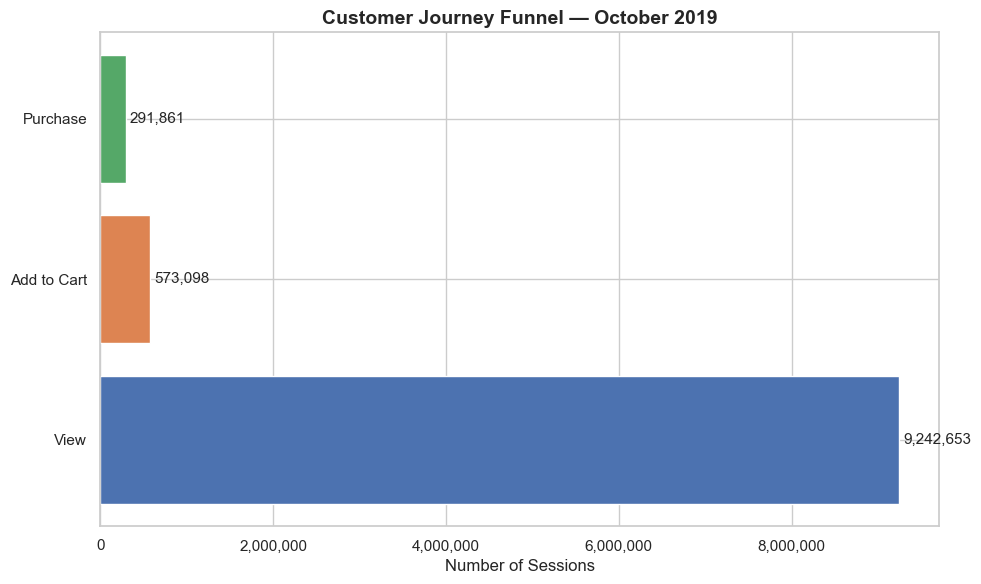

In [10]:
# Funnel data
stages = ['View', 'Add to Cart', 'Purchase']
counts = [
    df[df['event_type'] == 'view']['user_session'].nunique(),
    total_cart_sessions,
    total_converted
]

colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(stages, counts, color=colors)

# Add value labels
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 50000, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=11)

ax.set_xlabel('Number of Sessions')
ax.set_title('Customer Journey Funnel — October 2019', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../5_dashboard/funnel_chart.png', dpi=150)
plt.show()

## 5. Abandonment by Category
Identify which product categories have the highest cart abandonment rates.

In [12]:
# Filter to cart and purchase events only
cart_df = df[df['event_type'] == 'cart'][['user_session', 'category_code']].copy()
purchase_df = df[df['event_type'] == 'purchase'][['user_session']].copy()

# Flag sessions that converted
purchase_sessions_set = set(purchase_df['user_session'])
cart_df['converted'] = cart_df['user_session'].isin(purchase_sessions_set)

# Remove nulls in category_code
cart_df = cart_df.dropna(subset=['category_code'])

# Extract top level category
cart_df['category'] = cart_df['category_code'].str.split('.').str[0]

# Calculate abandonment rate per category
category_stats = cart_df.groupby('category').agg(
    total_carts=('user_session', 'count'),
    converted=('converted', 'sum')
).reset_index()

category_stats['abandonment_rate'] = ((1 - category_stats['converted'] / category_stats['total_carts']) * 100).round(2)
category_stats = category_stats[category_stats['total_carts'] > 1000]
category_stats = category_stats.sort_values('abandonment_rate', ascending=False)

print(category_stats.head(10))

        category  total_carts  converted  abandonment_rate
11         sport         1015        369             63.65
9           kids         2534        996             60.69
8      furniture         2331       1007             56.80
5   construction        10081       4681             53.57
3           auto         8916       4277             52.03
4      computers        26821      12870             52.02
2     appliances        89371      43953             50.82
7    electronics       653156     372565             42.96


### 5.1 Abandonment Rate by Category

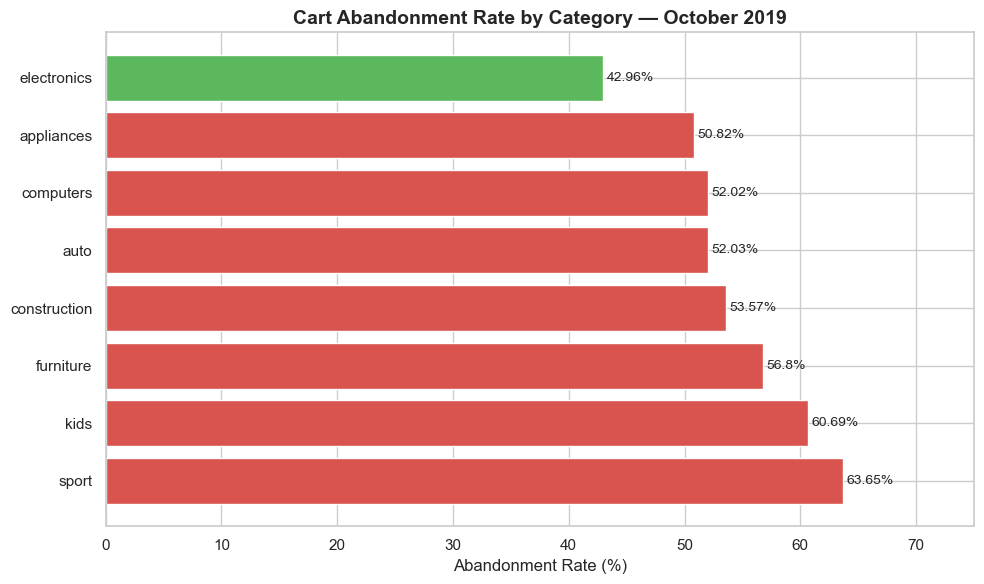

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#d9534f' if x > 50 else '#f0ad4e' if x > 43 else '#5cb85c' 
          for x in category_stats['abandonment_rate']]

bars = ax.barh(category_stats['category'], 
               category_stats['abandonment_rate'], 
               color=colors)

# Add value labels
for bar, val in zip(bars, category_stats['abandonment_rate']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)

ax.set_xlabel('Abandonment Rate (%)')
ax.set_title('Cart Abandonment Rate by Category — October 2019', 
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 75)
plt.tight_layout()
plt.savefig('../5_dashboard/abandonment_by_category.png', dpi=150)
plt.show()

## 6. Abandonment by Hour of Day
Identify peak abandonment times to inform when to trigger recovery emails.

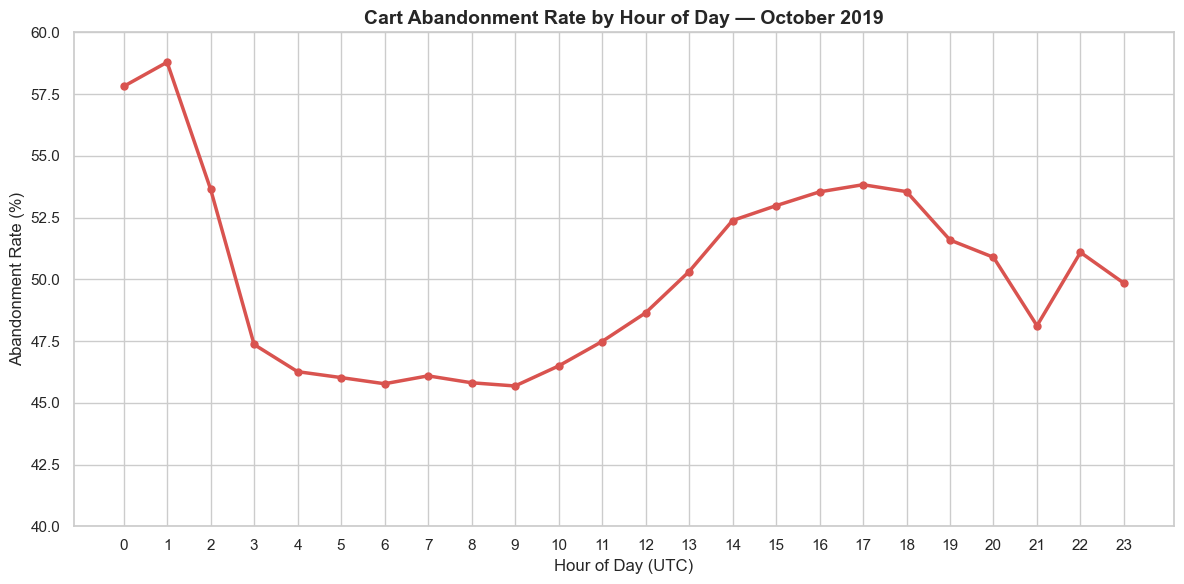

In [15]:
# Get cart and purchase sessions by hour
cart_hour = df[df['event_type'] == 'cart'][['user_session', 'hour']].drop_duplicates()
purchase_hour = df[df['event_type'] == 'purchase'][['user_session']].drop_duplicates()

cart_hour['converted'] = cart_hour['user_session'].isin(purchase_sessions_set)

hour_stats = cart_hour.groupby('hour').agg(
    total_carts=('user_session', 'count'),
    converted=('converted', 'sum')
).reset_index()

hour_stats['abandonment_rate'] = ((1 - hour_stats['converted'] / hour_stats['total_carts']) * 100).round(2)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(hour_stats['hour'], hour_stats['abandonment_rate'], 
        color='#d9534f', linewidth=2.5, marker='o', markersize=5)

ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Abandonment Rate (%)')
ax.set_title('Cart Abandonment Rate by Hour of Day — October 2019', 
             fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.set_ylim(40, 60)
plt.tight_layout()
plt.savefig('../5_dashboard/abandonment_by_hour.png', dpi=150)
plt.show()

## 7. Abandonment by Day of Week
Identify which days see the highest cart abandonment.

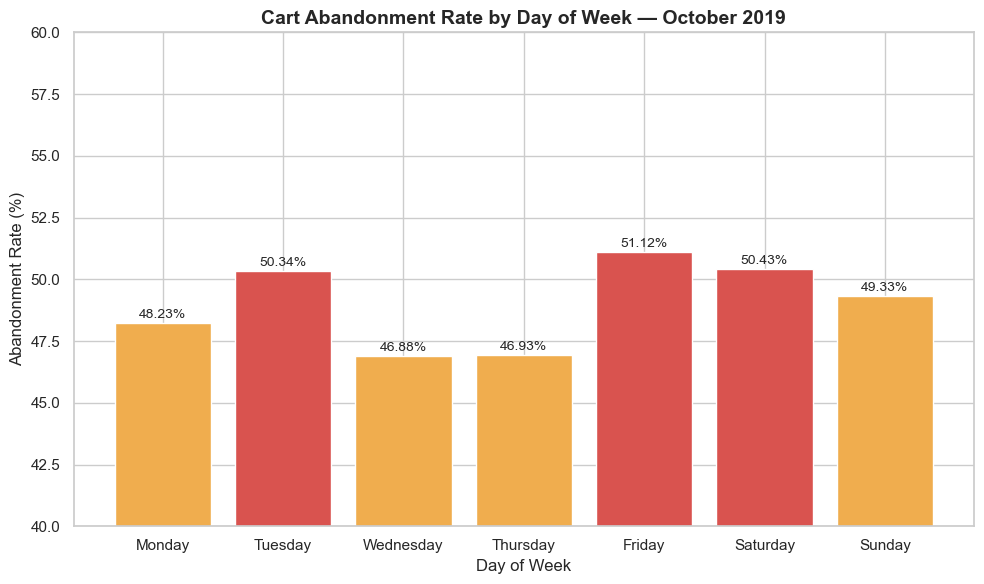

In [16]:
cart_day = df[df['event_type'] == 'cart'][['user_session', 'day_of_week']].drop_duplicates()
cart_day['converted'] = cart_day['user_session'].isin(purchase_sessions_set)

day_stats = cart_day.groupby('day_of_week').agg(
    total_carts=('user_session', 'count'),
    converted=('converted', 'sum')
).reset_index()

day_stats['abandonment_rate'] = ((1 - day_stats['converted'] / day_stats['total_carts']) * 100).round(2)

# Order days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_stats['day_of_week'] = pd.Categorical(day_stats['day_of_week'], categories=day_order, ordered=True)
day_stats = day_stats.sort_values('day_of_week')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d9534f' if x > 50 else '#f0ad4e' for x in day_stats['abandonment_rate']]
bars = ax.bar(day_stats['day_of_week'], day_stats['abandonment_rate'], color=colors)

for bar, val in zip(bars, day_stats['abandonment_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val}%', ha='center', fontsize=10)

ax.set_xlabel('Day of Week')
ax.set_ylabel('Abandonment Rate (%)')
ax.set_title('Cart Abandonment Rate by Day of Week — October 2019',
             fontsize=14, fontweight='bold')
ax.set_ylim(40, 60)
plt.tight_layout()
plt.savefig('../5_dashboard/abandonment_by_day.png', dpi=150)
plt.show()

## 8. Deeper Analysis

### 8.1 Average Price of Abandoned Items by Category
Explore whether price plays a role in cart abandonment across categories.

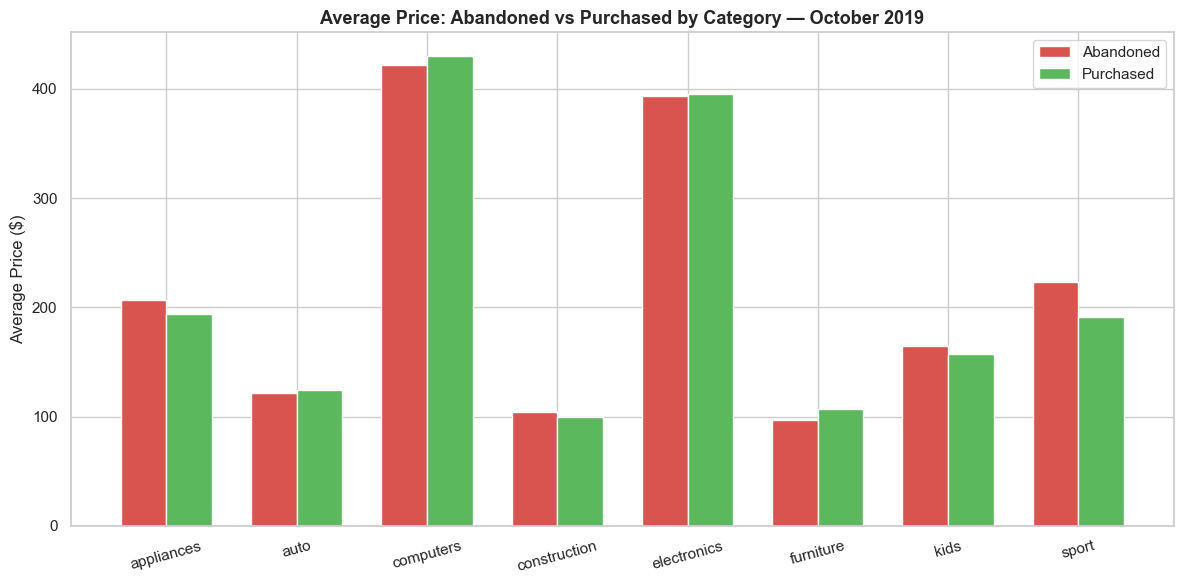

In [17]:
# Get abandoned cart events with price and category
cart_events = df[df['event_type'] == 'cart'][['user_session', 'category_code', 'price']].copy()
cart_events = cart_events.dropna(subset=['category_code'])
cart_events['category'] = cart_events['category_code'].str.split('.').str[0]
cart_events['converted'] = cart_events['user_session'].isin(purchase_sessions_set)

# Average price of abandoned vs converted carts by category
price_stats = cart_events.groupby(['category', 'converted']).agg(
    avg_price=('price', 'mean')
).reset_index()

price_stats['converted'] = price_stats['converted'].map({True: 'Purchased', False: 'Abandoned'})
price_stats = price_stats[price_stats['category'].isin(category_stats['category'])]
price_stats['avg_price'] = price_stats['avg_price'].round(2)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
categories = price_stats['category'].unique()
x = range(len(categories))
width = 0.35

abandoned = price_stats[price_stats['converted'] == 'Abandoned'].set_index('category')
purchased = price_stats[price_stats['converted'] == 'Purchased'].set_index('category')

bars1 = ax.bar([i - width/2 for i in x], 
               [abandoned.loc[c, 'avg_price'] if c in abandoned.index else 0 for c in categories],
               width, label='Abandoned', color='#d9534f')
bars2 = ax.bar([i + width/2 for i in x],
               [purchased.loc[c, 'avg_price'] if c in purchased.index else 0 for c in categories],
               width, label='Purchased', color='#5cb85c')

ax.set_xticks(list(x))
ax.set_xticklabels(categories, rotation=15)
ax.set_ylabel('Average Price ($)')
ax.set_title('Average Price: Abandoned vs Purchased by Category — October 2019',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../5_dashboard/price_by_category.png', dpi=150)
plt.show()

### 8.2 Most Abandoned Specific Products
Identify the top products added to cart but never purchased.

In [19]:
# Get all cart events
cart_products = df[df['event_type'] == 'cart'][['user_session', 'product_id', 'category_code', 'brand', 'price']].copy()
cart_products['converted'] = cart_products['user_session'].isin(purchase_sessions_set)

# Filter to abandoned only
abandoned_products = cart_products[cart_products['converted'] == False]

# Top 10 most abandoned products
top_abandoned = abandoned_products.groupby(['product_id', 'category_code', 'brand', 'price']).agg(
    times_abandoned=('user_session', 'count')
).reset_index().sort_values('times_abandoned', ascending=False).head(10)

top_abandoned['potential_revenue_lost'] = (top_abandoned['times_abandoned'] * top_abandoned['price']).round(2)

print(top_abandoned.to_string(index=False))

 product_id          category_code   brand  price  times_abandoned  potential_revenue_lost
    1004856 electronics.smartphone samsung 131.53             3185               418923.05
    1004856 electronics.smartphone samsung 131.64             2919               384257.16
    1004856 electronics.smartphone samsung 130.99             2434               318829.66
    1005115 electronics.smartphone   apple 975.56             2001              1952095.56
    1801690   electronics.video.tv samsung 369.37             1798               664127.26
    1002633 electronics.smartphone   apple 358.57             1780               638254.60
    1004856 electronics.smartphone samsung 131.51             1621               213177.71
    1004777 electronics.smartphone  xiaomi 135.01             1575               212640.75
    1004741 electronics.smartphone  xiaomi 189.97             1566               297493.02
    1004741 electronics.smartphone  xiaomi 190.22             1561               296933.42

### 8.2 Most Abandoned Products — Potential Revenue Lost

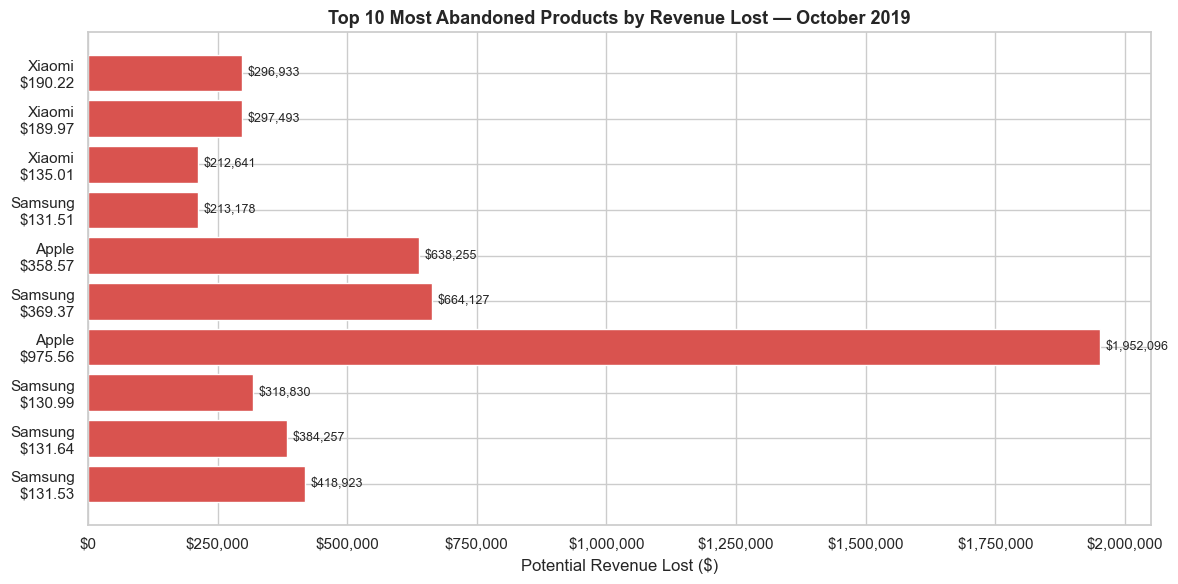

In [23]:
top_abandoned['label'] = top_abandoned['brand'].str.title() + '\n$' + top_abandoned['price'].astype(str)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_abandoned['label'], 
               top_abandoned['potential_revenue_lost'],
               color='#d9534f')

for bar, val in zip(bars, top_abandoned['potential_revenue_lost']):
    ax.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)

ax.set_xlabel('Potential Revenue Lost ($)')
ax.set_title('Top 10 Most Abandoned Products by Revenue Lost — October 2019',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
plt.tight_layout()
plt.savefig('../5_dashboard/top_abandoned_products.png', dpi=150)
plt.show()

### 8.3 Average Time Between Cart and Purchase
Understand how long customers take to convert — informing when to send recovery emails.

Average time to purchase:  3.8 minutes
Median time to purchase:   1.8 minutes
75th percentile:           3.7 minutes
90th percentile:           7.4 minutes


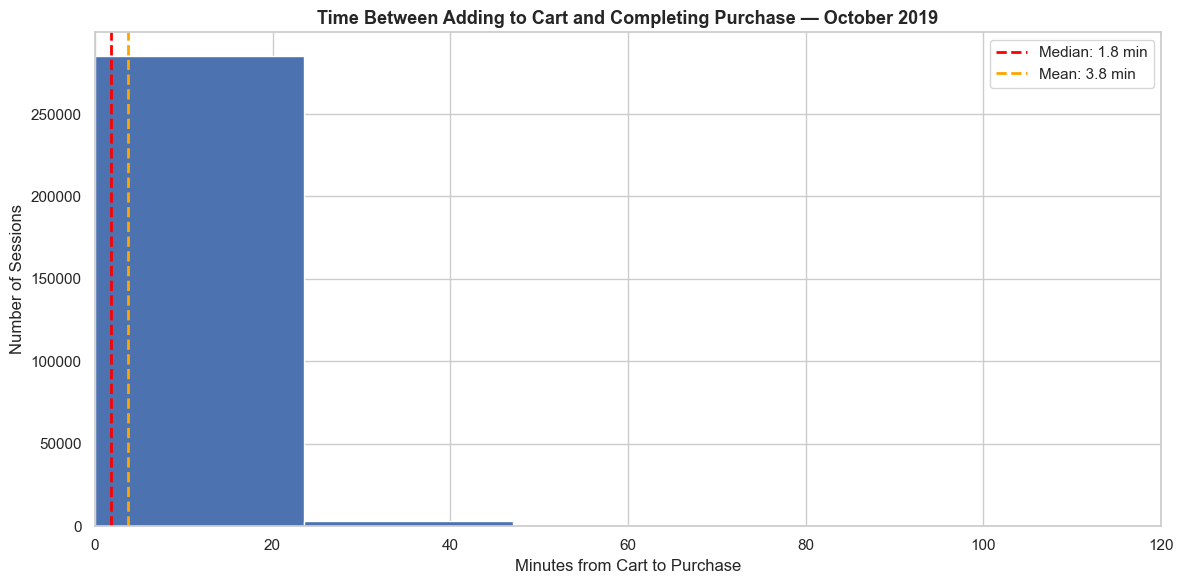

In [24]:
# Get cart and purchase events for converted sessions only
cart_times = df[df['event_type'] == 'cart'][['user_session', 'event_time']].copy()
purchase_times = df[df['event_type'] == 'purchase'][['user_session', 'event_time']].copy()

# Rename for clarity
cart_times.columns = ['user_session', 'cart_time']
purchase_times.columns = ['user_session', 'purchase_time']

# Keep earliest cart and latest purchase per session
cart_times = cart_times.groupby('user_session')['cart_time'].min().reset_index()
purchase_times = purchase_times.groupby('user_session')['purchase_time'].max().reset_index()

# Merge on converted sessions only
time_df = cart_times.merge(purchase_times, on='user_session')

# Calculate time difference in minutes
time_df['minutes_to_purchase'] = (
    (time_df['purchase_time'] - time_df['cart_time'])
    .dt.total_seconds() / 60
).round(2)

# Filter out negatives and extreme outliers
time_df = time_df[(time_df['minutes_to_purchase'] >= 0) & 
                   (time_df['minutes_to_purchase'] <= 1440)]  # within 24 hours

# Summary stats
print(f"Average time to purchase:  {time_df['minutes_to_purchase'].mean():.1f} minutes")
print(f"Median time to purchase:   {time_df['minutes_to_purchase'].median():.1f} minutes")
print(f"75th percentile:           {time_df['minutes_to_purchase'].quantile(0.75):.1f} minutes")
print(f"90th percentile:           {time_df['minutes_to_purchase'].quantile(0.90):.1f} minutes")

# Plot distribution
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(time_df['minutes_to_purchase'], bins=60, color='#4C72B0', edgecolor='white')
ax.axvline(time_df['minutes_to_purchase'].median(), color='red', 
           linestyle='--', linewidth=2, label=f"Median: {time_df['minutes_to_purchase'].median():.1f} min")
ax.axvline(time_df['minutes_to_purchase'].mean(), color='orange', 
           linestyle='--', linewidth=2, label=f"Mean: {time_df['minutes_to_purchase'].mean():.1f} min")

ax.set_xlabel('Minutes from Cart to Purchase')
ax.set_ylabel('Number of Sessions')
ax.set_title('Time Between Adding to Cart and Completing Purchase — October 2019',
             fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlim(0, 120)
plt.tight_layout()
plt.savefig('../5_dashboard/time_to_purchase.png', dpi=150)
plt.show()

### 8.4 Timezone Analysis — Who is Shopping at 3–9am UTC?
Low abandonment at 3–9am UTC may reflect peak shopping hours in specific regions.
Mapping UTC hours to local timezones to identify the platform's core customer base.

In [25]:
# Map UTC hours to key timezones
timezone_offsets = {
    'UTC+0 (UK/Portugal)': 0,
    'UTC+1 (Central Europe)': 1,
    'UTC+3 (Moscow/Gulf)': 3,
    'UTC+5.5 (India)': 5.5,
    'UTC+8 (China/Singapore)': 8,
    'UTC-5 (US East Coast)': -5,
    'UTC-8 (US West Coast)': -8,
}

print("What time is it locally when UTC hour = 3-9 (lowest abandonment)?")
print("-" * 60)
for region, offset in timezone_offsets.items():
    local_start = (3 + offset) % 24
    local_end = (9 + offset) % 24
    print(f"{region:<30} → {local_start:.0f}:00 – {local_end:.0f}:00")

print("\nWhat time is it locally when UTC hour = 0-1 (highest abandonment)?")
print("-" * 60)
for region, offset in timezone_offsets.items():
    local_start = (0 + offset) % 24
    local_end = (1 + offset) % 24
    print(f"{region:<30} → {local_start:.0f}:00 – {local_end:.0f}:00")

What time is it locally when UTC hour = 3-9 (lowest abandonment)?
------------------------------------------------------------
UTC+0 (UK/Portugal)            → 3:00 – 9:00
UTC+1 (Central Europe)         → 4:00 – 10:00
UTC+3 (Moscow/Gulf)            → 6:00 – 12:00
UTC+5.5 (India)                → 8:00 – 14:00
UTC+8 (China/Singapore)        → 11:00 – 17:00
UTC-5 (US East Coast)          → 22:00 – 4:00
UTC-8 (US West Coast)          → 19:00 – 1:00

What time is it locally when UTC hour = 0-1 (highest abandonment)?
------------------------------------------------------------
UTC+0 (UK/Portugal)            → 0:00 – 1:00
UTC+1 (Central Europe)         → 1:00 – 2:00
UTC+3 (Moscow/Gulf)            → 3:00 – 4:00
UTC+5.5 (India)                → 6:00 – 6:00
UTC+8 (China/Singapore)        → 8:00 – 9:00
UTC-5 (US East Coast)          → 19:00 – 20:00
UTC-8 (US West Coast)          → 16:00 – 17:00


### 8.4 Timezone Interpretation — UTC Hours Mapped to Local Time

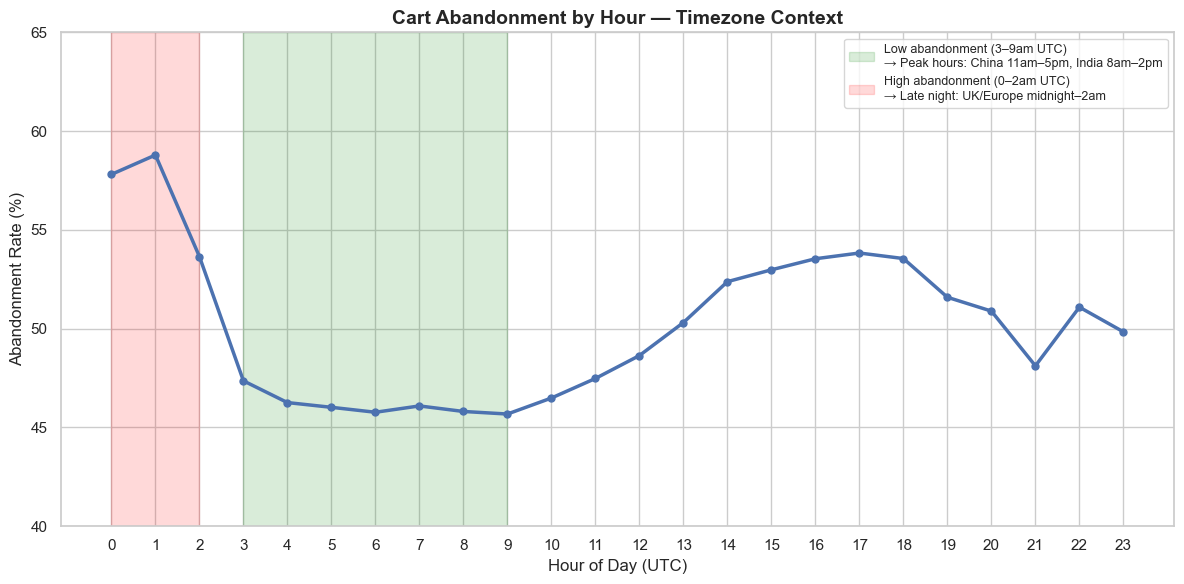

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot abandonment rate by hour
ax.plot(hour_stats['hour'], hour_stats['abandonment_rate'],
        color='#4C72B0', linewidth=2.5, marker='o', markersize=5)

# Highlight low abandonment window
ax.axvspan(3, 9, alpha=0.15, color='green', label='Low abandonment (3–9am UTC)\n→ Peak hours: China 11am–5pm, India 8am–2pm')

# Highlight high abandonment window
ax.axvspan(0, 2, alpha=0.15, color='red', label='High abandonment (0–2am UTC)\n→ Late night: UK/Europe midnight–2am')

ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Abandonment Rate (%)')
ax.set_title('Cart Abandonment by Hour — Timezone Context', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.set_ylim(40, 65)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('../5_dashboard/abandonment_hour_timezone.png', dpi=150)
plt.show()

### 8.5 Category Preference by Hour
Compare what categories are most purchased during low abandonment hours (3–9am UTC)
vs high abandonment hours (0–2am UTC) to understand buyer intent by region.

In [27]:
# Get purchase events with category and hour
purchase_cat_hour = df[df['event_type'] == 'purchase'][['hour', 'category_code']].copy()
purchase_cat_hour = purchase_cat_hour.dropna(subset=['category_code'])
purchase_cat_hour['category'] = purchase_cat_hour['category_code'].str.split('.').str[0]

# Split into two windows
low_abandon = purchase_cat_hour[purchase_cat_hour['hour'].between(3, 9)]
high_abandon = purchase_cat_hour[purchase_cat_hour['hour'].between(0, 2)]

# Count purchases by category in each window
low_counts = low_abandon['category'].value_counts(normalize=True).mul(100).round(2).head(6)
high_counts = high_abandon['category'].value_counts(normalize=True).mul(100).round(2).head(6)

print("Top categories purchased during LOW abandonment hours (3–9am UTC):")
print(low_counts.to_string())
print("\nTop categories purchased during HIGH abandonment hours (0–2am UTC):")
print(high_counts.to_string())

Top categories purchased during LOW abandonment hours (3–9am UTC):
category
electronics    74.20
appliances     13.64
computers       4.84
auto            1.78
construction    1.40
furniture       1.39

Top categories purchased during HIGH abandonment hours (0–2am UTC):
category
electronics    72.61
appliances     13.28
computers       5.04
auto            2.23
furniture       1.78
construction    1.74


### 8.5 Category Mix — Low vs High Abandonment Hours

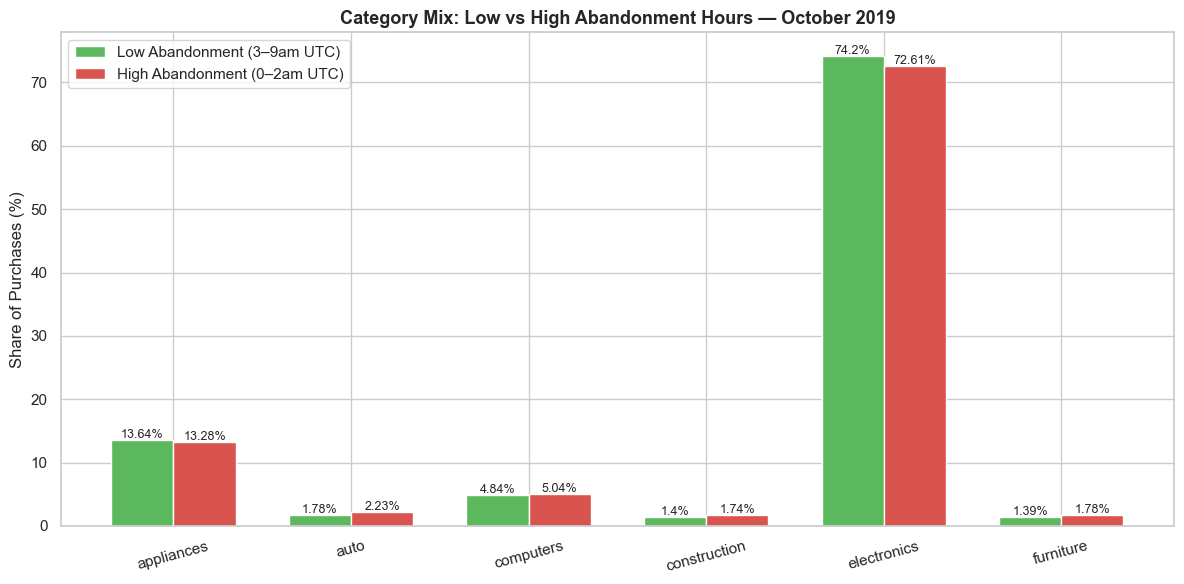

In [28]:
import numpy as np

categories = low_counts.index.union(high_counts.index)
low_vals = [low_counts.get(c, 0) for c in categories]
high_vals = [high_counts.get(c, 0) for c in categories]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, low_vals, width, label='Low Abandonment (3–9am UTC)', color='#5cb85c')
bars2 = ax.bar(x + width/2, high_vals, width, label='High Abandonment (0–2am UTC)', color='#d9534f')

for bar, val in zip(bars1, low_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=9)
for bar, val in zip(bars2, high_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=15)
ax.set_ylabel('Share of Purchases (%)')
ax.set_title('Category Mix: Low vs High Abandonment Hours — October 2019',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../5_dashboard/category_by_hour.png', dpi=150)
plt.show()

### 8.6 Volume of Carts by Hour
Are low abandonment hours also low traffic? If so, the impact may be smaller than it appears.

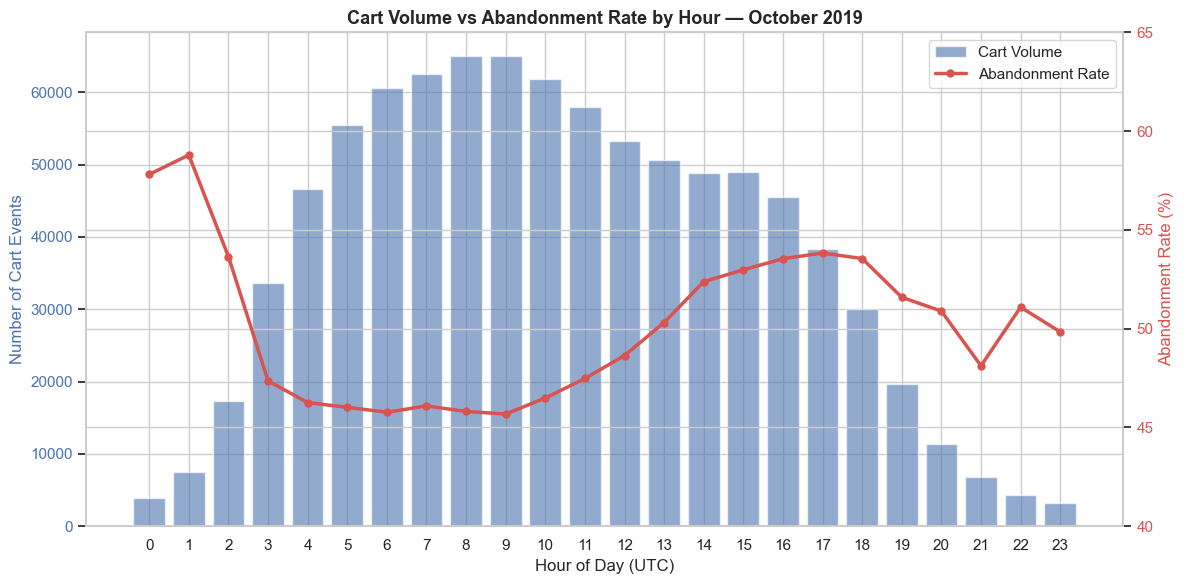

In [29]:
# Cart volume by hour
cart_volume = df[df['event_type'] == 'cart'].groupby('hour')['user_session'].count().reset_index()
cart_volume.columns = ['hour', 'cart_count']

fig, ax1 = plt.subplots(figsize=(12, 6))

# Volume bars
ax1.bar(cart_volume['hour'], cart_volume['cart_count'], 
        color='#4C72B0', alpha=0.6, label='Cart Volume')
ax1.set_xlabel('Hour of Day (UTC)')
ax1.set_ylabel('Number of Cart Events', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')

# Abandonment rate line on secondary axis
ax2 = ax1.twinx()
ax2.plot(hour_stats['hour'], hour_stats['abandonment_rate'],
         color='#d9534f', linewidth=2.5, marker='o', markersize=5, label='Abandonment Rate')
ax2.set_ylabel('Abandonment Rate (%)', color='#d9534f')
ax2.tick_params(axis='y', labelcolor='#d9534f')
ax2.set_ylim(40, 65)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title('Cart Volume vs Abandonment Rate by Hour — October 2019',
              fontsize=13, fontweight='bold')
ax1.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig('../5_dashboard/volume_vs_abandonment_hour.png', dpi=150)
plt.show()

### 8.7 Repeat Behaviour — Do Abandoners Come Back and Buy?
Identify whether users who abandon their cart in one session return to purchase in a later session.

Total unique users who abandoned at least once: 206,958
Of those, users who purchased in any session:   72,614 (35.1%)
Of those, users who never purchased at all:     134,344 (64.9%)


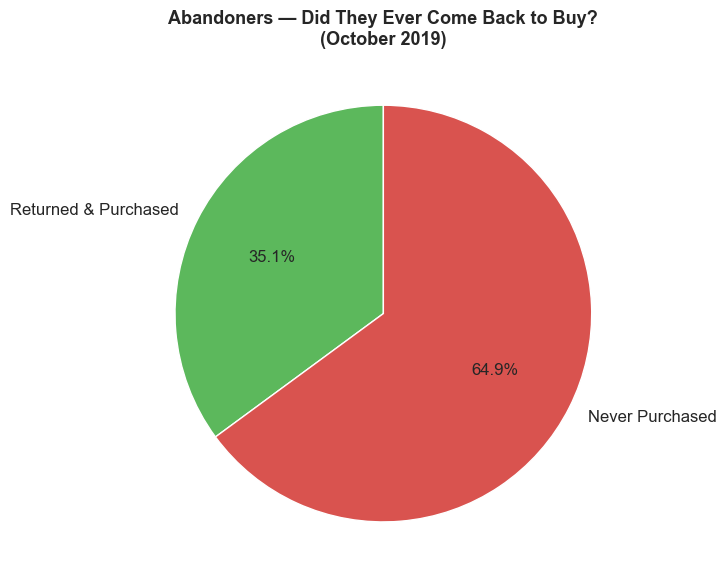

In [30]:
# Get all users who abandoned in at least one session
abandoner_users = df[df['user_session'].isin(abandoned_sessions)]['user_id'].unique()

# Get all users who purchased in any session
purchaser_users = df[df['event_type'] == 'purchase']['user_id'].unique()

# Abandoners who eventually purchased in a different session
returned_and_bought = set(abandoner_users) & set(purchaser_users)
never_returned = set(abandoner_users) - set(purchaser_users)

total_abandoners = len(abandoner_users)
returned = len(returned_and_bought)
never = len(never_returned)

print(f"Total unique users who abandoned at least once: {total_abandoners:,}")
print(f"Of those, users who purchased in any session:   {returned:,} ({returned/total_abandoners*100:.1f}%)")
print(f"Of those, users who never purchased at all:     {never:,} ({never/total_abandoners*100:.1f}%)")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
labels = ['Returned & Purchased', 'Never Purchased']
values = [returned, never]
colors = ['#5cb85c', '#d9534f']
wedges, texts, autotexts = ax.pie(values, labels=labels, colors=colors,
                                   autopct='%1.1f%%', startangle=90,
                                   textprops={'fontsize': 12})
ax.set_title('Abandoners — Did They Ever Come Back to Buy?\n(October 2019)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../5_dashboard/repeat_behaviour.png', dpi=150)
plt.show()

### 8.8 Brand Analysis — Which Brands Have the Highest Abandonment Rate?
Identify whether certain brands suffer disproportionately from cart abandonment.

In [31]:
# Get cart events with brand
cart_brand = df[df['event_type'] == 'cart'][['user_session', 'brand']].copy()
cart_brand = cart_brand.dropna(subset=['brand'])
cart_brand['converted'] = cart_brand['user_session'].isin(purchase_sessions_set)

# Calculate abandonment rate per brand
brand_stats = cart_brand.groupby('brand').agg(
    total_carts=('user_session', 'count'),
    converted=('converted', 'sum')
).reset_index()

brand_stats['abandonment_rate'] = ((1 - brand_stats['converted'] / brand_stats['total_carts']) * 100).round(2)

# Filter to brands with meaningful volume
brand_stats = brand_stats[brand_stats['total_carts'] > 5000]
brand_stats = brand_stats.sort_values('abandonment_rate', ascending=False).head(15)

print(brand_stats.to_string(index=False))

   brand  total_carts  converted  abandonment_rate
cordiant         5513       2233             59.50
  xiaomi       101951      46881             54.02
    sony         9861       4583             53.52
   bosch         6965       3282             52.88
   haier         5585       2721             51.28
 philips         6311       3088             51.07
 indesit         6523       3212             50.76
elenberg         8301       4093             50.69
 redmond         5681       2833             50.13
      lg        13061       6554             49.82
    beko         5477       2772             49.39
   artel         6213       3231             48.00
    acer         9153       4780             47.78
   apple       203757     116448             42.85
  huawei        40753      23744             41.74


### 8.8 Brand Abandonment Rate

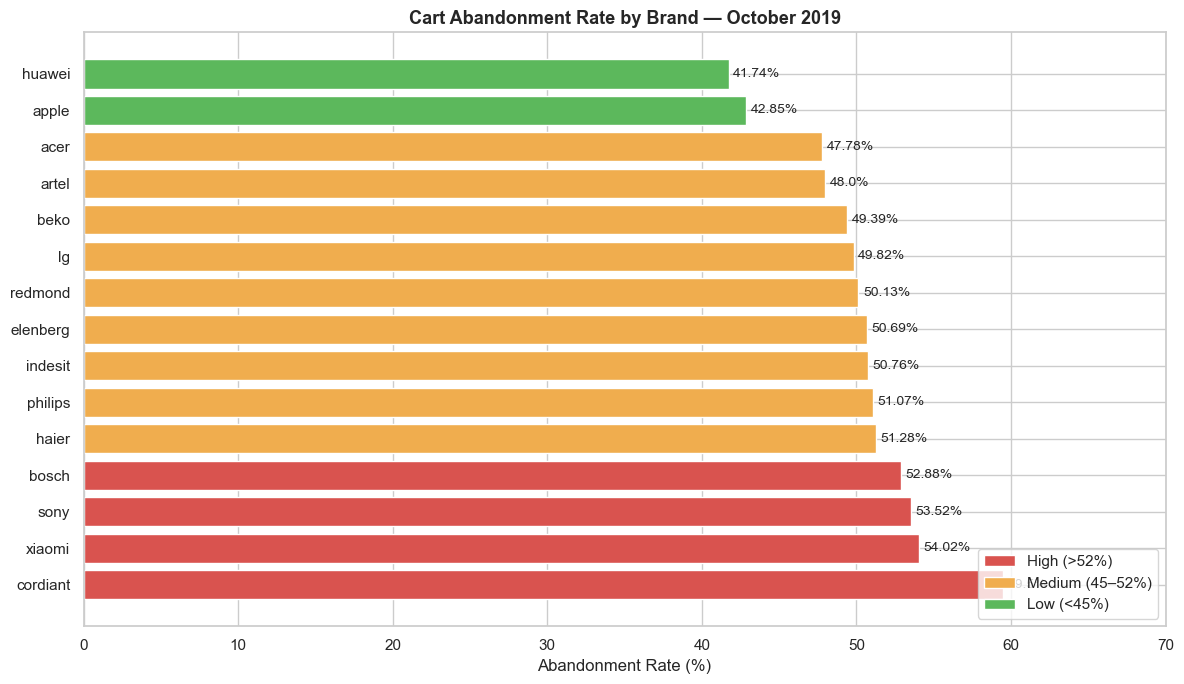

In [32]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#d9534f' if x > 52 else '#f0ad4e' if x > 45 else '#5cb85c' 
          for x in brand_stats['abandonment_rate']]

bars = ax.barh(brand_stats['brand'], brand_stats['abandonment_rate'], color=colors)

for bar, val in zip(bars, brand_stats['abandonment_rate']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)

ax.set_xlabel('Abandonment Rate (%)')
ax.set_title('Cart Abandonment Rate by Brand — October 2019',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 70)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d9534f', label='High (>52%)'),
                   Patch(facecolor='#f0ad4e', label='Medium (45–52%)'),
                   Patch(facecolor='#5cb85c', label='Low (<45%)')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../5_dashboard/abandonment_by_brand.png', dpi=150)
plt.show()

## 9. Key Findings Summary

| Finding | Value |
|---|---|
| Total sessions analysed | 9,242,653 |
| Sessions that added to cart | 573,098 |
| Sessions that completed purchase | 291,861 |
| Cart abandonment rate | 49.07% |
| Highest abandonment category | Sport (63.65%) |
| Lowest abandonment category | Electronics (42.96%) |
| Highest abandonment hour | 1am UTC (58.9%) |
| Lowest abandonment hour | 9am UTC (45.6%) |
| Best trading window | 5–9am UTC — peak volume AND lowest abandonment |
| Highest abandonment day | Friday (51.12%) |
| Lowest abandonment day | Thursday (46.93%) |
| Median time cart to purchase | 1.8 minutes |
| 90% of purchases occur within | 7.4 minutes of adding to cart |
| Top revenue opportunity | Apple smartphone — $1.95M lost in Oct |
| Price drives abandonment? | No — abandoned vs purchased prices near identical |
| Category drives abandonment? | No — same categories bought at all hours |
| Abandoners who self-recovered | 35.1% (72,614 users) |
| Abandoners who never purchased | 64.9% (134,344 users) |
| Highest abandonment brand | Cordiant (59.5%) |
| Lowest abandonment brand | Huawei (41.7%) |